# Final Exam, DSCI 311 Fall 25
## Due Date: Friday 12/12 by 9:00 AM PST

**Collaboration Policy: No collaboration is allowed on this test. All work must be your own.**

**Chat GPT and other AI**: The use of AI tools is forbidden on this exam. If asked, you should be prepared to explain how any piece of code works and why you wrote it the way you did. 

**Note that for ALL plotting questions, we will expect appropriate titles, axis labels, legends, etc. The following question serves as a good guideline on what is "enough": If I directly downloaded the plot and viewed it, would I be able to tell what was being visualized without knowing the question?** 

This final covers most topics touched on in the course, as well as one or two covered in DSCI 102. You should feel free to use: past homeworks, labs, lecture slides, lecture notebooks, class textbooks and even google/stack overflow/AI to help you answer these questions.

You may be expected to do things that we have not explicitly shown in class or in an assignment - this is intentional, and why we expect you to reference function documentation (*e.g.* `help(pd.read_csv)`) or internet resources (e.g. Stack Overflow/AI) for help. But most of what you will do will have been shown either in lecture (in slides or in lecture notebooks) or in assignments.

We provide cells for your answers but you should break out your answers into as many cells as you'd like to answer them.

**Grader tests**: There are no grader tests in the final. Be sure to read all questions carefully.

When you are finished, please 'Restart and Clear Output' in the Kernel Menu
Then execute **every** code cell.
Then 'Save and Checkpoint' in the File Menu, followed by 'Close and Halt' in the File Menu
Then submit your fully executed notebook to the Canvas Final assignment

**You must submit by 9:00am on Friday, 12 December**. I strongly recommend you submit the exam by Thursday evening in the event you run into any issues with Canvas.

In [677]:
# import all modules that you require here
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

# ill import as I go on, but these are standard after seeing past assignments 

import statsmodels.api as sm
import statsmodels.formula.api as smf

import sklearn
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
#similar imports from cross-validation.ipynb week 8 lecture

## Part 1: Oregon Fires Over Time

The following data contains records of every wildfire in Oregon between 2000 and 2022. All of us at this point are familiar with fire season in the late summer in Eugene - it would be interesting to evaluate trends in these fires over time! 

First read in `ODF_Fire_occurence_Data_2000-2022.csv`, which contains various descriptive variables pertaining to every wildfire during this timeframe.

In [678]:
fire = pd.read_csv('data/ODF_Fire_Occurrence_Data_2000-2022.csv') #the text above spells the csv file wrong
fire.columns

Index(['Serial', 'FireCategory', 'Area', 'DistrictName', 'UnitName',
       'FullFireNumber', 'FireName', 'Size_class', 'EstTotalAcres',
       'Protected_Acres', 'HumanOrLightning', 'CauseBy', 'GeneralCause',
       'SpecificCause', 'Cause_Comments', 'Lat_DD', 'Long_DD', 'LatLongDD',
       'FO_LandOwnType', 'Twn', 'Rng', 'Sec', 'Subdiv', 'LandmarkLocation',
       'County', 'RegUseZone', 'RegUseRestriction', 'Industrial_Restriction',
       'Ign_DateTime', 'ReportDateTime', 'Discover_DateTime',
       'Control_DateTime', 'CreationDate', 'ModifiedDate', 'DistrictCode',
       'UnitCode', 'DistFireNumber'],
      dtype='object')

In [679]:
fire.head()

,Serial,FireCategory,Area,DistrictName,UnitName,FullFireNumber,FireName,Size_class,EstTotalAcres,Protected_Acres,...,Industrial_Restriction,Ign_DateTime,ReportDateTime,Discover_DateTime,Control_DateTime,CreationDate,ModifiedDate,DistrictCode,UnitCode,DistFireNumber
0,102649,STAT,EOA,Klamath-Lake,Klamath,15-981082-16,Bass 497,B,3.20,3.20,...,Does Not Apply - Eastern OR,9/2/2015 17:00,9/2/2015 17:05,9/2/2015 17:00,9/2/2015 23:00,9/5/2015 0:00,10/13/2015 8:39,98,981,82
1,131239,STAT,EOA,Walker Range - WRFPA,Crescent,22-991220-23,Hay Fire,A,NaN,0.20,...,NaN,NaN,8/16/2022 18:56,NaN,NaN,8/18/2022 0:00,8/18/2022 9:11,99,991,220
2,58256,STAT,EOA,Central Oregon,John Day,00-952011-01,Slick Ear #2,B,0.75,0.75,...,Does Not Apply - Eastern OR,7/18/2000 19:00,7/19/2000 13:20,7/19/2000 13:15,7/20/2000 0:50,7/20/2000 9:13,11/14/2000 9:16,95,952,11
3,59312,STAT,EOA,Northeast Oregon,La Grande,00-971024-01,Woodley,C,80.00,80.00,...,Does Not Apply - Eastern OR,8/24/2000 5:30,8/24/2000 13:07,8/24/2000 13:07,9/1/2000 21:30,8/29/2000 15:59,12/21/2000 16:22,97,971,24
4,61657,STAT,SOA,Southwest Oregon,Grants Pass,01-712133-02,QUEENS BRANCH,A,0.10,0.10,...,Lvl 3 Restricted Shutdown,8/10/2001 17:40,8/10/2001 17:47,8/10/2001 17:45,8/10/2001 18:30,8/10/2001 18:42,8/17/2001 11:45,71,712,133


#### Question 1.1

To analyze trends through time, we'll first need to create two new columns in `fire` called "Year" and "Year_Month". Derive these variables from `ReportDateTime` by whatever means you'd like.

In [680]:
# fire[['ReportDateTime']] filtering to just that single column to see how it's laid out 

In [681]:
# type(fire['ReportDateTime'][0]) string type 

# fire['Year'] = fire['ReportDateTime'].str.split('/').str[2].str.split(' ').str[0]
# this first splits strings by /, then we filter the last section unsplitted by / and split it by " space "
# then select the first part of the string


# fire['Year_Month'] = fire['Year'] + '-' + fire['ReportDateTime'].str.split('/').str[0]
# here, i add the year that i extracted earlier, and then do the same thing again for reportdatetime but just extract the month

# fire[['Year', 'Year_Month']]

# i just realized here that i cant actually sort them for the next problem since when i try to, it thinks that 
# month '10' is sooner than anything between '1-9', so i need to add a zero at the beginning for all months that
# are 1-9. Also, pandas does have a converting function pd.to_datetime that i used back in homework 5, so lets
# ignore what we did above and use that approach instead which makes it cleaner and easier.

# got["created_at"] = pd.to_datetime(got['created_at'], format = '%m/%d/%Y %H:%M') exactly used from hoemwork 5

fire['Year'] = pd.to_datetime(fire['ReportDateTime'], format = '%m/%d/%Y %H:%M').dt.year.astype(str)
#extracts year
fire['Year_Month'] = pd.to_datetime(fire['ReportDateTime'], format = '%m/%d/%Y %H:%M').dt.to_period('m').astype(str)
# extracts month for the given year, since i assume that year_month wants both the year and month in order

# converted both to string, since for the next problem, having a pd.to_datetime format wouldnt let me plot

fire[['Year', 'Year_Month']]

/var/folders/53/qn2bqxzd489fdf7zn6smrbtw0000gn/T/ipykernel_97565/2079170337.py:22: FutureWarning: 'm' is deprecated and will be removed in a future version, please use 'M' instead.
  fire['Year_Month'] = pd.to_datetime(fire['ReportDateTime'], format = '%m/%d/%Y %H:%M').dt.to_period('m').astype(str)


,Year,Year_Month
0,2015,2015-09
1,2022,2022-08
2,2000,2000-07
3,2000,2000-08
4,2001,2001-08
...,...,...
23485,2021,2021-06
23486,2022,2022-09
23487,2021,2021-06
23488,2022,2022-08


#### Question 1.2

Now plot a time series of the total number of fires for each year and month combination in the data. The values should be plotted in chronological order i.e. March 2000 should be the first month and November 2022 the last. Don't worry about making the x axis labels readable.

Text(0.5, 1.0, 'Fire counts for each month for each year (Mar.2000 - Nov. 2022)')

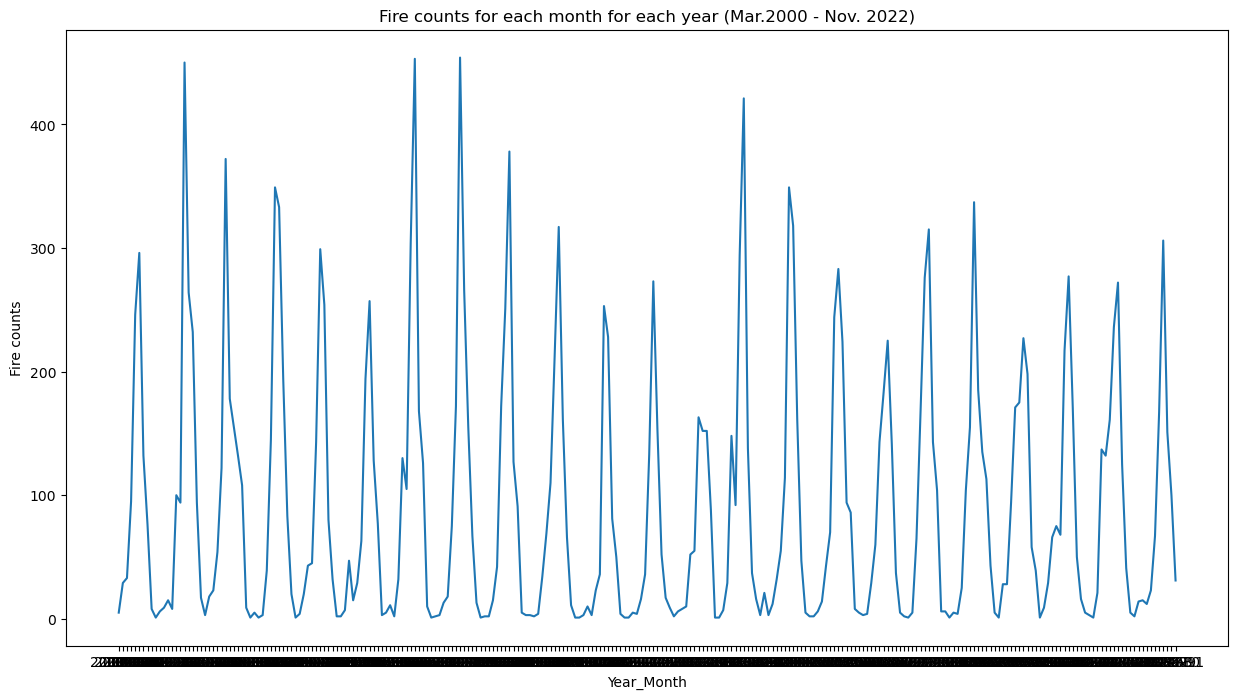

In [682]:
fire.sort_values(by = 'Year_Month') # since we have multiple fires per day, we want to group them by month

fires = fire.groupby('Year_Month').size().reset_index()
fires = fires.sort_values(by = 'Year_Month').rename(columns = {0: 'fire count'})

plt.figure(figsize = (15, 8))
sns.lineplot(data = fires, x = 'Year_Month', y = 'fire count')
plt.ylabel('Fire counts')
plt.title('Fire counts for each month for each year (Mar.2000 - Nov. 2022)')

What are two things you observe about fires through time

**Your response**: After plotting the graph, we can see that there are many spikes along the graph and they seem to be pretty consistant. We can say that this could be due to fires in the summertime, when the temperature is higher and more probable to spreading wildfire in forests, etc. Another thing we notice just by glancing at the graph is that the peaks throughout the years fluctuate a lot, but the highest points at the beginning are slowly becoming shorter as we go throughout the years. Nonetheless, this graph shows pretty well how seasons change the amount of fires that happen, with its low and high points. 

#### Question 1.3

Sum the total acreage burned in each year (`EstTotalAcres`), then visualize the association with a seaborn `regplot`. Ensure that the confidence interval around the best-fit line is visible. Then, based on the line and visualized confidence interval, how confident do you feel in the slope?

Text(0.5, 1.0, 'Total Acres burned per each year (2000-2022)')

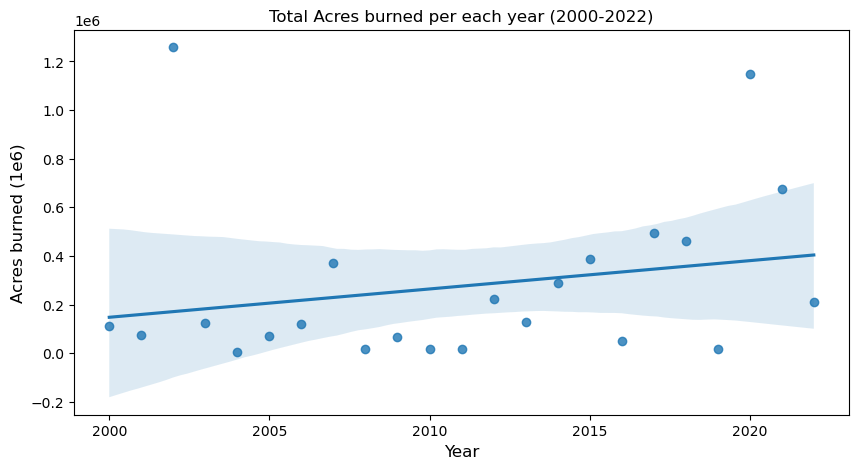

In [683]:
acreage = fire.groupby('Year')['EstTotalAcres'].sum().reset_index()


plt.figure(figsize = (10, 5))

# sns.regplot(data = acreage, x = 'Year', y = 'EstTotalAcres')
acreage['Year'] = acreage['Year'].astype(int) # was getting an error prior to doing this

sns.regplot(data = acreage, x = 'Year', y = 'EstTotalAcres')
plt.xlabel('Year', fontsize = 12)
plt.ylabel('Acres burned (1e6)', fontsize = 12)
plt.title('Total Acres burned per each year (2000-2022)')

**Your response**: This graph tells a different story. We can see that throughout the years, our graph tells us that fire acreage burning has slightly increased over time. On the other hand though, our confidence interval is pretty wide, with two extreme outlier points at the beggining and towards the end. On our other points, they fluctuate a low throughout the graph, meaning that this slope isn't probably the most accurate, or the best representative line. I feel like 50/50 on the slope, just because of how wide our variance is.

#### Question 1.4

You should see a generally positive association between the two variables. However, we don't conclude anything statistical from visualization alone. 

Use [statsmodels](https://www.statsmodels.org/stable/index.html) to fit linear a model and evaluate the summary output. What is your confidence in the slope of the line in terms of the p-value and confidence interval?

In [684]:
# # Load data
# data_url = "https://raw.githubusercontent.com/nguyen-toan/ISLR/07fd968ea484b5f6febc7b392a28eb64329a4945/dataset/Advertising.csv"
# df = pd.read_csv(data_url).drop('Unnamed: 0', axis=1)
# df.head()
# # Fitting linear model
# res = smf.ols(formula= "Sales ~ TV + Radio + Newspaper", data=df).fit()
# res.summary()
# this is from the statsmodels website, their example 

results = smf.ols(formula = 'EstTotalAcres ~ Year',data = acreage).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          EstTotalAcres   R-squared:                       0.053
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     1.166
Date:                Tue, 09 Dec 2025   Prob (F-statistic):              0.293
Time:                        19:24:33   Log-Likelihood:                -324.75
No. Observations:                  23   AIC:                             653.5
Df Residuals:                      21   BIC:                             655.8
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -2.315e+07   2.17e+07     -1.067      0.298   -6.83e+07     2.2e+07
Year        1.165e+04   1.08e+04      1.080      0.293   -1.08e+04    3.41e+04
==============================================================================
Omnibus:                       22.015   Durbin-Watson:                   2.109
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               28.942
Skew:                           2.012   Prob(JB):                     5.19e-07
Kurtosis:                       6.742   Cond. No.                     6.10e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.1e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

**Your response**: Our results give us a p-value of 0.293 which is much larger than the base 0.05. Our range/95% confidence interval ranges from -1.08e+04 -- 3.41e+04, and there is a lot of varaibility in our data (far points). Due to this, it's hard to say that our slope that we got earlier is statisitcally significant, because we don't have a strong evidence to show our upward trend and our variance / confidence intervals are wide too. 

#### Question 1.5

Returning to the scatterplot, there does appear to be a pretty considerable outlier early in the time series. Filter that point out of the data, then repeat q1.4.

Text(0.5, 1.0, 'Total Acres burned per each year (2000-2022)')

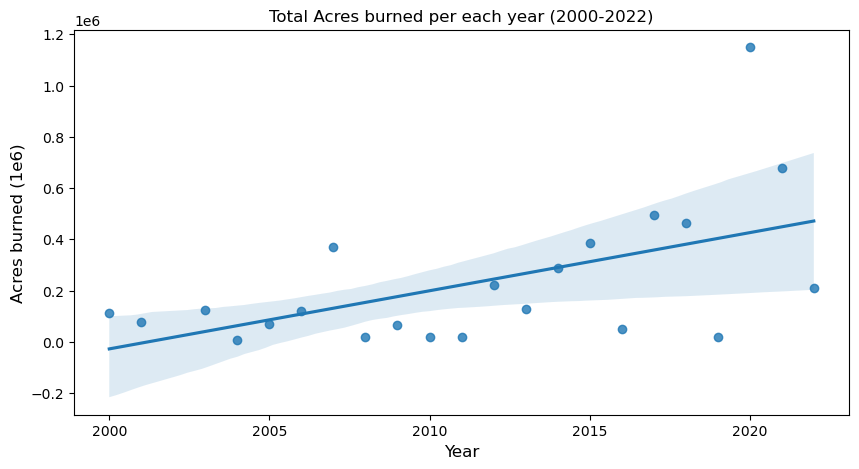

In [685]:
filtered = acreage[acreage['EstTotalAcres'] < 1200000] #had to filter like this since we are only taking out one point 

plt.figure(figsize = (10, 5))

sns.regplot(data = filtered, x = 'Year', y = 'EstTotalAcres')

plt.xlabel('Year', fontsize = 12)
plt.ylabel('Acres burned (1e6)', fontsize = 12)
plt.title('Total Acres burned per each year (2000-2022)')

In [686]:
results = smf.ols(formula = 'EstTotalAcres ~ Year',data = filtered).fit()
results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          EstTotalAcres   R-squared:                       0.298
Model:                            OLS   Adj. R-squared:                  0.263
Method:                 Least Squares   F-statistic:                     8.489
Date:                Tue, 09 Dec 2025   Prob (F-statistic):            0.00859
Time:                        19:24:33   Log-Likelihood:                -302.44
No. Observations:                  22   AIC:                             608.9
Df Residuals:                      20   BIC:                             611.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept   -4.54e+07   1.57e+07     -2.899      0.009   -7.81e+07   -1.27e+07
Year        2.268e+04   7785.625      2.914      0.009    6443.976    3.89e+04
==============================================================================
Omnibus:                       11.670   Durbin-Watson:                   2.258
Prob(Omnibus):                  0.003   Jarque-Bera (JB):               10.755
Skew:                           1.150   Prob(JB):                      0.00462
Kurtosis:                       5.538   Cond. No.                     6.23e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.23e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

How does removing the outlier change your confidence in the slope? Do you think it's valid to remove the outlier in this case? Justify your answer.

**Your response**: we now have a p value of 0.00859 < 0.05. Our confidence intervals are also now 6443.976 -- 3.89e+04. With these changes, our p-value is now below 0.05, which means we have a stronger and more significant association/relation between year and the total acres burned. We can also visually see our slope is positively steeper. In terms of removing this outlier, I would say that it depends on what is being asked to see if it's appropriate to remove it or not.

For example, if we wanted to look at long term trends of fires throughout like decades, this could skew our results because it could be a one time thing where the fires were really bad one year, and it could skew our results.

If we wanted to look at a specific year or like the amount of U.S. dollars spent on combatting wildfires per year, this outlier would need to stay to make sure we have the most accurate answers possible. 

#### Question 1.6

For this question, we're going to compare the burn times of fires started by humans and fires started by lightning. 

1. Create a new variable called `Burn_time_days` that represents the time difference between `Control_DateTime` and `ReportDateTime` in units of days. Because there are a few erroneous date entries that render a negative difference, subset the resulting data for only burn times greater than 0.
2. Visualize two overlapping distributions of the **log-transformed** burn times of human-started fires vs lightning-started fires (`HumanOrLightning` in the data). Ensure the distributions are different colors.

In [687]:
fire['Burn_time_days'] = (pd.to_datetime(
    fire['Control_DateTime'], format = '%m/%d/%Y %H:%M') - pd.to_datetime(
    fire['ReportDateTime'], format = '%m/%d/%Y %H:%M')).dt.total_seconds()

# doing dt.days sets days between 0-1 to 0. this wont work since we still have positive values that 
# fall under hours between days. so lets convert our difference to units in seconds and from there 
# multiply to make them into days. 


fire['Burn_time_days'] = fire['Burn_time_days'] / 86400   # after a quick search, there are 86400 seconds in a day
fire = fire[fire['Burn_time_days'] > 0 ]# this ensures we don't have any lurking negative values
fire

,Serial,FireCategory,Area,DistrictName,UnitName,FullFireNumber,FireName,Size_class,EstTotalAcres,Protected_Acres,...,Discover_DateTime,Control_DateTime,CreationDate,ModifiedDate,DistrictCode,UnitCode,DistFireNumber,Year,Year_Month,Burn_time_days
0,102649,STAT,EOA,Klamath-Lake,Klamath,15-981082-16,Bass 497,B,3.20,3.20,...,9/2/2015 17:00,9/2/2015 23:00,9/5/2015 0:00,10/13/2015 8:39,98,981,82,2015,2015-09,0.246528
2,58256,STAT,EOA,Central Oregon,John Day,00-952011-01,Slick Ear #2,B,0.75,0.75,...,7/19/2000 13:15,7/20/2000 0:50,7/20/2000 9:13,11/14/2000 9:16,95,952,11,2000,2000-07,0.479167
3,59312,STAT,EOA,Northeast Oregon,La Grande,00-971024-01,Woodley,C,80.00,80.00,...,8/24/2000 13:07,9/1/2000 21:30,8/29/2000 15:59,12/21/2000 16:22,97,971,24,2000,2000-08,8.349306
4,61657,STAT,SOA,Southwest Oregon,Grants Pass,01-712133-02,QUEENS BRANCH,A,0.10,0.10,...,8/10/2001 17:45,8/10/2001 18:30,8/10/2001 18:42,8/17/2001 11:45,71,712,133,2001,2001-08,0.029861
5,98529,STAT,SOA,Douglas - DFPA,DFPA Central,14-733192-15,Chilcoot,A,0.01,0.01,...,8/13/2014 16:00,8/14/2014 18:30,8/21/2014 0:00,8/24/2014 11:54,73,733,192,2014,2014-08,1.103472
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23485,124548,STAT,EOA,Walker Range - WRFPA,Crescent,21-991258-21,Road 2430,B,0.75,0.75,...,6/26/2021 16:45,6/26/2021 21:58,7/1/2021 0:00,10/2/2021 15:08,99,991,258,2021,2021-06,0.208333
23486,132141,STAT,SOA,Western Lane,Veneta,22-781066-23,Spruce Path,A,0.01,0.01,...,9/13/2022 11:20,9/13/2022 12:14,9/13/2022 0:00,9/19/2022 10:09,78,781,66,2022,2022-09,0.037500
23487,124065,STAT,EOA,Northeast Oregon,Pendleton,21-973052-21,Bone Canyon,C,67.43,67.43,...,6/14/2021 12:45,6/17/2021 17:10,6/14/2021 0:00,9/24/2021 13:48,97,973,52,2021,2021-06,3.184028
23488,131292,STAT,EOA,Northeast Oregon,Pendleton,22-973014-23,Milepost 231,A,0.10,0.00,...,8/19/2022 15:09,8/19/2022 16:41,8/19/2022 0:00,11/8/2022 11:34,97,973,14,2022,2022-08,0.063889


Text(0.5, 1.0, 'Human vs. Lightning (log) started fires to burn times')

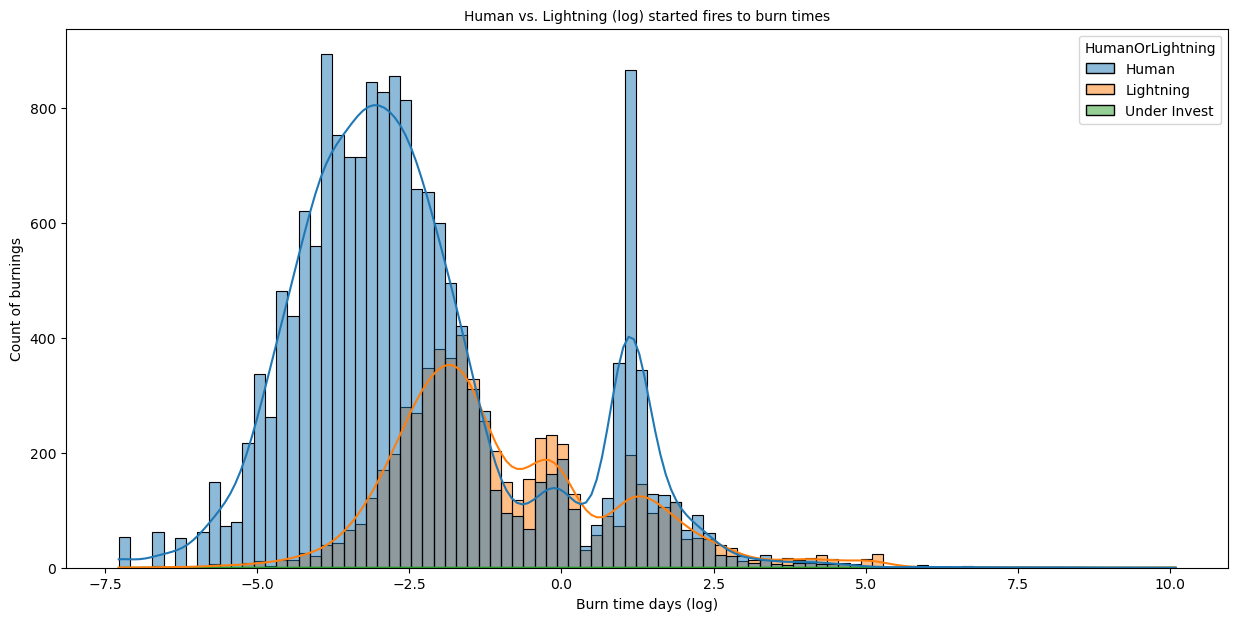

In [688]:
plt.figure(figsize = (15, 7))

sns.histplot(data = fire, x = np.log(fire['Burn_time_days']), hue = 'HumanOrLightning', kde = True)

plt.xlabel('Burn time days (log)', fontsize = 10)
plt.ylabel('Count of burnings', fontsize = 10)
plt.title('Human vs. Lightning (log) started fires to burn times', fontsize = 10)

How do fires of different ignition sources differ? Describe in terms of characteristics of the distributions. 

And is there anything odd about the distributions? If so, provide a plausible interpretation.

**Your response**: In general, we see a way larger volume of fires being started by humans vs. lightning. Human started fires roughly have shorter burn time compared to lightning fires. We can see that fires started by lightning are shifted to the right, meaning that they are longer fires. What I do find odd though is the large spike at 1.00 log , where all of a sudden there is a large volume of fires started by humans (and all the same duration). My thinking is that this could be an event, or something specific where it's defaulted and not significant in any other way.

## Part 2: COVID Excess Mortality

You may remember that COVID was once a big deal, killing 1.2+ million people in the U.S. as of today. As the disease potentially becomes endemic i.e. a regular player in the annual disease cycle, its severity has declined with growing immunity (Virulence Attenuation; but, newly emerged strains could regain severity, much like the flu). Lest we "memory hole" its significance, it could be interesting to look back and do some visualization.

A useful method for estimating Covid-related mortality at the national level is by calculating "excess mortality". Excess mortality is the observed mortality in a year over some running average; often a 10-year average. Thus, we can infer covid-related mortality by attributing it to mortality not associated with all-cause "business-as-usual" background rates. 

*This section is comparatively open-ended*. I would encourage you to play around with the data in some of the questions by creating different country comparisons to see what's interesting.

In [689]:
# Read in covid excess mortality data
excess_mort = pd.read_csv('data/national_excess_mortality.csv')
excess_mort.head()

,COUNTRY,Country,WEEK,GENDER,Gender,Age,VARIABLE,Variable,YEAR,Year,Value
0,CZE,Czech Republic,46,TOTAL,Total,0 to 44,EXCESSNB,Excess deaths (number),2020,2020,2.2
1,CZE,Czech Republic,46,TOTAL,Total,0 to 44,EXCESSNB,Excess deaths (number),2021,2021,8.2
2,NLD,Netherlands,3,TOTAL,Total,65 and over,EXCESSNB,Excess deaths (number),2020,2020,-127.4
3,NLD,Netherlands,3,TOTAL,Total,65 and over,EXCESSNB,Excess deaths (number),2021,2021,569.6
4,NLD,Netherlands,3,TOTAL,Total,65 and over,EXCESSNB,Excess deaths (number),2022,2022,-73.4


#### Question 2.1

Look at the `Variable` column. Given that countries can vary by orders of magnitude in their population, which variable do you think will be best for comparing excess mortality between countries? Filter the data for this metric. Also, remove any redundant columns. 

In [690]:
excess_mort['Variable'].unique() # by looking at this, i would say that the best approach would be filtering data by the 
# excess deaths (% change from average), since every country is different in size and it wouldn't be right or correct to
# compare a country like russia to Spain

excess_filtered = excess_mort[excess_mort['Variable'] == 'Excess deaths (% change from average)']
excess_filtered = excess_filtered.drop(columns = ['COUNTRY', 'GENDER', 'VARIABLE', 'YEAR'])
excess_filtered

,Country,WEEK,Gender,Age,Variable,Year,Value
38466,Denmark,29,Males,45 to 64,Excess deaths (% change from average),2020,1.0
38467,Denmark,29,Males,45 to 64,Excess deaths (% change from average),2021,4.7
38468,Estonia,47,Males,45 to 64,Excess deaths (% change from average),2020,32.4
38469,Estonia,47,Males,45 to 64,Excess deaths (% change from average),2021,35.3
38473,Luxembourg,40,Males,Total,Excess deaths (% change from average),2020,-4.0
...,...,...,...,...,...,...,...
82597,United States,53,Total,0 to 44,Excess deaths (% change from average),2020,37.4
82598,United States,53,Total,45 to 64,Excess deaths (% change from average),2020,39.3
82599,United States,53,Total,65 and over,Excess deaths (% change from average),2020,50.8
82604,United States,53,Total,Total,Excess deaths (% change from average),2020,48.1


#### Question 2.2

What is the temporal granularity of excess death reporting?

"Temporal granularity is the level of detail or resolution at which time is measured or described"

**Your response**: For our data, our temporal granularity is going to be weeks, since our data is reported by weeks on each row, with different data following it. 

#### Question 2.3

Our goal is to look at the change in excess mortality through time. Create a new column in the dataframe representing time as a continous quantity by whatever method you see fit, then subset your data for TOTAL gender and Total age (you don't need to sum the two sexes, there is a factor level for this in the data). 

In [691]:
# We have both year and week on time, so let's create one

# there are 52 weeks in a year, but due to having a leap year every 4 years, we found 52.1429 online with a calculator. (rough est.)
excess_filtered['time'] =  excess_filtered['Year'] + excess_filtered['WEEK'] / 52.1429

excess_filtered = excess_filtered[ (excess_filtered['Gender'] == 'Total') & (excess_filtered['Age'] == 'Total') ] 
# & symbol gives us both statements

excess_filtered

,Country,WEEK,Gender,Age,Variable,Year,Value,time
38475,Belgium,18,Total,Total,Excess deaths (% change from average),2020,20.7,2020.345205
38476,Belgium,18,Total,Total,Excess deaths (% change from average),2021,12.5,2021.345205
38477,Belgium,18,Total,Total,Excess deaths (% change from average),2022,11.5,2022.345205
38497,Denmark,37,Total,Total,Excess deaths (% change from average),2020,3.6,2020.709588
38498,Denmark,37,Total,Total,Excess deaths (% change from average),2021,10.6,2021.709588
...,...,...,...,...,...,...,...,...
81782,Canada,53,Total,Total,Excess deaths (% change from average),2020,15.1,2021.016438
81829,Australia,53,Total,Total,Excess deaths (% change from average),2020,4.3,2021.016438
82205,Germany,53,Total,Total,Excess deaths (% change from average),2020,35.7,2021.016438
82604,United States,53,Total,Total,Excess deaths (% change from average),2020,48.1,2021.016438


#### Question 2.4 

Create two subplots: (1) excess mortality in the US and Canada through the entire time series and (2) the same but for two other nearby countries (e.g. in Europe) of your choice. 

Ensure that there are separate lines for each country, a legend for each subplot, that there are two subplots, and you're using the correct kind of graph for this relationship.

Text(0.5, 1.0, 'Excess mortality throughout the years (France & Spain)')

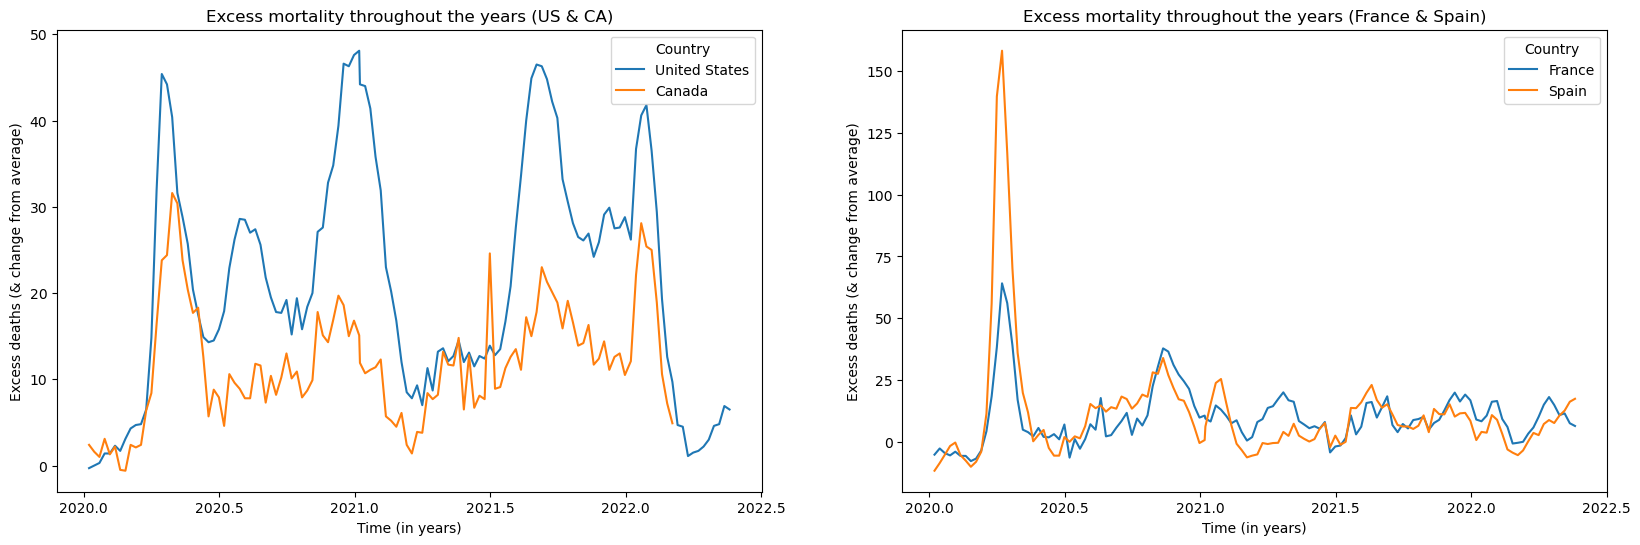

In [692]:
NA = excess_filtered[excess_filtered['Country'].isin(['United States', 'Canada'])]
EU = excess_filtered[excess_filtered['Country'].isin(['Spain', 'France'])]

fig, axis = plt.subplots(1, 2, figsize = (20, 6))

sns.lineplot(data = NA, x = 'time', y = 'Value', hue = 'Country', ax = axis[0])
axis[0].set_xlabel('Time (in years)')
axis[0].set_ylabel('Excess deaths (& change from average)')
axis[0].set_title('Excess mortality throughout the years (US & CA)')

sns.lineplot(data = EU, x = 'time', y = 'Value', hue = 'Country', ax = axis[1])
axis[1].set_xlabel('Time (in years)')
axis[1].set_ylabel('Excess deaths (& change from average)')
axis[1].set_title('Excess mortality throughout the years (France & Spain)')

#### Question 2.5

What do you notice about excess mortality through time? Are the patterns different in the US and Canada compared to your other two countries? Describe at least three things you notice. 

**Your response**: From our first graph (US vs CA), we see that they are some upward points where both countries experienced a rise on excess deaths around the same time (same with France in Spain). For US vs. CA, we do see though that the US has much more excess death throughout most of its period and has very sharp peaks that are extreme compared to their lowes. For Canada, it keeps a pretty low excess death percentage number but has it's own peaks (aren't as high). 

For our second graph (France vs. Spain), we see that towards the middle of 2020, Spain and France both had a very high volume of excess deaths (with Spain's peak being substantually larger), and both afterwards kept a steady and low rate after that. 

As far as comparing both graphs to one another, one similarity they have is the inital peak/rise of covid during 2020.

#### Question 2.6

Make another comparison of excess mortality rates of your choice. This should involve a visualization (1 plot or more) and a summary statistic if relevant. Then explain (1) what you can infer from the comparison you made and (2) how you might follow up with a new analysis, including new data collection if needed.

Text(0.5, 1.0, 'Excess mortality thoughout the years (Germany and Poland)')

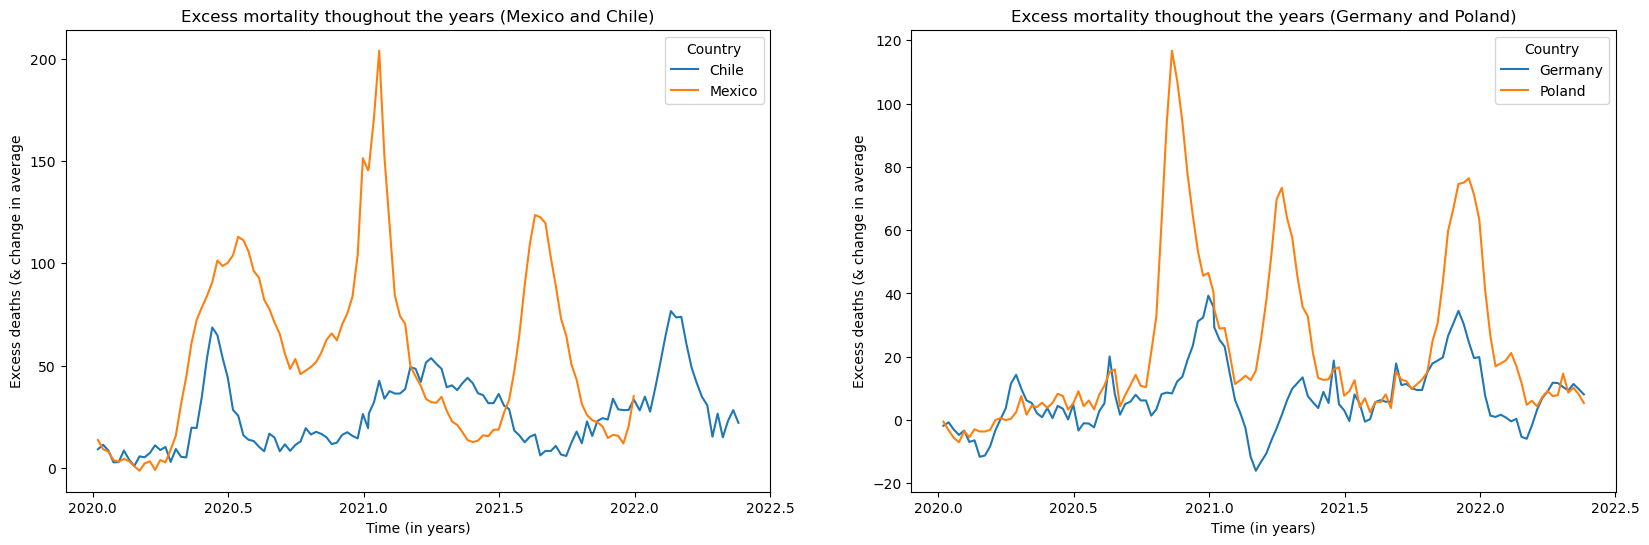

In [693]:
MEXCHI = excess_filtered[excess_filtered['Country'].isin(['Mexico', 'Chile'])]

GERPOL = excess_filtered[excess_filtered['Country'].isin(['Germany', 'Poland'])]

fig, axis = plt.subplots(1, 2, figsize = (20, 6))

sns.lineplot(data = MEXCHI, x = 'time', y = 'Value', hue = 'Country', ax = axis[0])
axis[0].set_xlabel('Time (in years)')
axis[0].set_ylabel('Excess deaths (& change in average')
axis[0].set_title('Excess mortality thoughout the years (Mexico and Chile)')

sns.lineplot(data = GERPOL, x = 'time', y = 'Value', hue = 'Country', ax = axis[1])
axis[1].set_xlabel('Time (in years)')
axis[1].set_ylabel('Excess deaths (& change in average')
axis[1].set_title('Excess mortality thoughout the years (Germany and Poland)')

**Your response**: 
For our first graph (Mexico vs. Chile), we see that both countries follow a similar trend in terms of their own uprise and low points on excess deaths. One thing we do notice is that Mexico has a higher overall excess death rate comapred to Chile, and had an extreme peak around the beginning of 2021. We also see that we don't have any more data from Mexico by 2022, so we aren't sure its trend afterwards. Chile keeps a relatively low excess death rate throughout the years.

For our second graph (Germany vs. Poland), we can see that Poland has had a few uprises and high peaks throughout the years, with its lows being short periods after. Overall, Poland has an average higher excess death rate compared to Germany. For Germany, we do see a couple high points, but relatively low excess death rate as well. We also see a low point for Germany, meaning there was a period where the excess death rates dropped dramatically and then rose again.

To follow up with new analysis, I would look into seeing when treatments and medicine started rolling out for these countries, and how they were enforced. Not only that, but I would also look at what preventative measures were taken place for each country and the age demographic for each country (since age was a factor on how severe covid affected somebody).

### Part 3: 2018-2019 Oregon Women's Basketball

In DSCI 101, you manipulated data from the Lady Duck's games from the 2019-2019 season; they had an excellent season, with a final four appearance.

As part of your analysis, you determined that there were some aspects of their performance from which one can predict whether they would win a game with high accuracy. In this part, you will derive optimal parameters for two logistic regression models.

A women's collegiate basketball game is divided into four 10-minute quarters; if the game is tied at the end of 4 quarters, 5-minute overtime periods are played until one team is ahead at the end of an overtime period.

The file `uo_women_basketball_18-19.csv` provides the raw statistics for the team's games during the 2018-19 season.

In [694]:
bbgames = pd.read_csv('data/uo_women_basketball_18-19.csv')
bbgames.head(5)

,Opponent,Location,Date,OrQ1,OrQ2,OrQ3,OrQ4,OpQ1,OpQ2,OpQ3,OpQ4,OrOT1,OpOT1
0,Alaska Fairbanks,AWAY,11/06/18,34,26,29,26,9,13,8,6,0,0
1,Syracuse,HOME,11/10/18,20,14,14,27,10,17,17,29,0,0
2,Utah State,AWAY,11/14/18,30,19,20,19,15,13,15,14,0,0
3,Buffalo,HOME,11/18/18,26,23,31,22,16,23,21,22,0,0
4,UC Riverside,HOME,11/23/18,23,29,25,17,11,7,13,13,0,0


#### Question 3.1

Add three columns to `bbgames`:
* OrTotal - Oregon's total points for the game
* OpTotal - the Opponent's total points for the game
* Result - 1 if Oregon won the game, 0 if Oregon lost the game

In [695]:
bbgames['OrTotal'] = bbgames[['OrQ1', 'OrQ2', 'OrQ3', 'OrQ4', 'OrOT1']].sum(axis = 1)
# take each column for oregon and add them all up given the row we are working on, axis = 1
# , we are operating across columns for each of the rows 

bbgames['OpTotal'] = bbgames[['OpQ1', 'OpQ2', 'OpQ3', 'OpQ4', 'OpOT1']].sum(axis = 1)

bbgames['Result'] = bbgames['OrTotal'] > bbgames['OpTotal'] # here, True means oregon won, 
# and false means oregon lost. lets convert this into 1 and 0, instead of a bool

bbgames['Result'] = bbgames['Result'].astype(int)

bbgames.head()


,Opponent,Location,Date,OrQ1,OrQ2,OrQ3,OrQ4,OpQ1,OpQ2,OpQ3,OpQ4,OrOT1,OpOT1,OrTotal,OpTotal,Result
0,Alaska Fairbanks,AWAY,11/06/18,34,26,29,26,9,13,8,6,0,0,115,36,1
1,Syracuse,HOME,11/10/18,20,14,14,27,10,17,17,29,0,0,75,73,1
2,Utah State,AWAY,11/14/18,30,19,20,19,15,13,15,14,0,0,88,57,1
3,Buffalo,HOME,11/18/18,26,23,31,22,16,23,21,22,0,0,102,82,1
4,UC Riverside,HOME,11/23/18,23,29,25,17,11,7,13,13,0,0,94,44,1


#### Question 3.2

The Lady Ducks were known for outscoring the opposition in the 1st quarter, and again in the 3rd quarter. We are going to use the fractional scoring differential in each quarters as our independent variables for our logistic regression models.

$Q1~fraction = \frac{Oregon~Q1~points~-~Opponent~Q1~points}{Oregon~Q1~points~+~Opponent~Q1~points}$

This fraction varies from -1 to 1

Add 4 columns to `bbgames`:
* Q1fraction - the fractional scoring differential for Q1
* Q2fraction - the fractional scoring differential for Q2
* Q3fraction - the fractional scoring differential for Q3
* Q4fraction - the fractional scoring differential for Q4

In [696]:
bbgames['Q1fraction'] = (bbgames['OrQ1'] - bbgames['OpQ1']) / (bbgames['OrQ1'] + bbgames['OpQ1'])

bbgames['Q2fraction'] = (bbgames['OrQ2'] - bbgames['OpQ2']) / (bbgames['OrQ2'] + bbgames['OpQ2'])

bbgames['Q3fraction'] = (bbgames['OrQ3'] - bbgames['OpQ3']) / (bbgames['OrQ3'] + bbgames['OpQ3'])

bbgames['Q4fraction'] = (bbgames['OrQ4'] - bbgames['OpQ4']) / (bbgames['OrQ4'] + bbgames['OpQ4'])

bbgames.head()

,Opponent,Location,Date,OrQ1,OrQ2,OrQ3,OrQ4,OpQ1,OpQ2,OpQ3,OpQ4,OrOT1,OpOT1,OrTotal,OpTotal,Result,Q1fraction,Q2fraction,Q3fraction,Q4fraction
0,Alaska Fairbanks,AWAY,11/06/18,34,26,29,26,9,13,8,6,0,0,115,36,1,0.581395,0.333333,0.567568,0.625000
1,Syracuse,HOME,11/10/18,20,14,14,27,10,17,17,29,0,0,75,73,1,0.333333,-0.096774,-0.096774,-0.035714
2,Utah State,AWAY,11/14/18,30,19,20,19,15,13,15,14,0,0,88,57,1,0.333333,0.187500,0.142857,0.151515
3,Buffalo,HOME,11/18/18,26,23,31,22,16,23,21,22,0,0,102,82,1,0.238095,0.000000,0.192308,0.000000
4,UC Riverside,HOME,11/23/18,23,29,25,17,11,7,13,13,0,0,94,44,1,0.352941,0.611111,0.315789,0.133333


#### Question 3.3

Create a scatter plot showing the result on the y-axis and Q1fraction on the x-axis. The limits on the x-axis should be \[-1,1\].

(-1.0, 1.0)

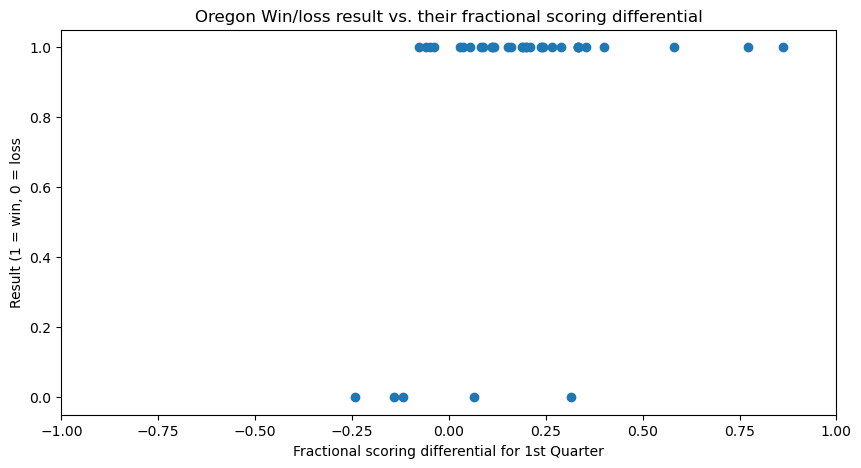

In [697]:
plt.figure(figsize = (10, 5))

plt.scatter(data = bbgames, x = 'Q1fraction', y = 'Result')

plt.xlabel('Fractional scoring differential for 1st Quarter')
plt.ylabel('Result (1 = win, 0 = loss')
plt.title('Oregon Win/loss result vs. their fractional scoring differential')
plt.xlim(-1, 1)

#### Question 3.4

We know that classification, such as winning or losing a game, requires that we use a model that predicts probabilities, and that we arrive at such a model assuming that the log-odds of the probability of yielding a win is linear. Classification is then determined by some choice of threshold (default 0.5).

For a single-feature logistic regression model, we have $P(Y=1|x)~=~\sigma(\theta_1~X_1)$, where $\sigma$ is the sigmoid function.

Define a function `sig(x)` below that returns the value of the sigmoid function for the value `x`. Then plot `sig(25*x)` over the range of \[-1, 1\].

In [698]:
# using week 7: lecture 'logistic_regression.ipynb' for reference

def sig(x):
    return 1 / (1 + np.exp(-x))

Text(0.5, 1.0, 'Sigmoid graph')

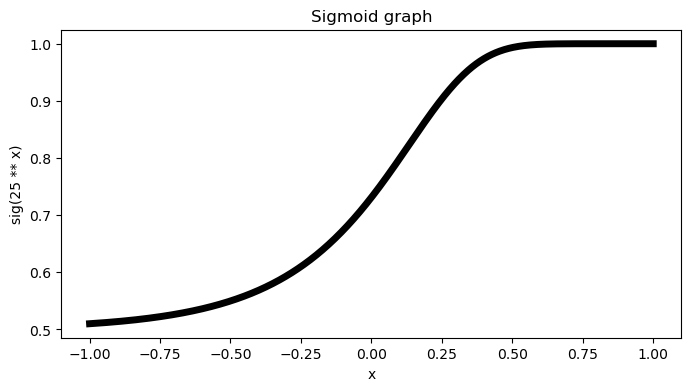

In [699]:
plt.figure(figsize = (8, 4))

# x = bbgames['Result'].index this is wrong, tried and gave me a really bad plot

x = np.linspace(-1, 1, 1000)

plt.plot(x, sig(25**x), 'black', linewidth = 5)

plt.xlabel('x')
plt.ylabel('sig(25 ** x)')
plt.title('Sigmoid graph')

#### Question 3.5

Now fit four single-feature logistic regression models *e.g.* $P(Y=1|x)~=~\sigma(\theta_0 + \theta_1~\cdot~Q_1fraction... + \theta_4~\cdot~Q_4fraction)$ for the fractional scoring difference in each of the four quarters and compare them with *k-fold cross-validation* by calculating the mean log loss of each model across the k validation sets. Use whatever *k* you prefer.  You can fit the model yourself with `sigma` and `minimize` and determine the loss yourself, or you can use sklearn's methods.

*Note*: If you use `LogisticRegression()` from 'sklearn', be sure to set the argument `C = 10000` (or higher). `LogisticRegression` implements regularization by default - good when we have multiple predictors and want to optimize for test error. Because we have a small dataset and just want to create the model of best fit on this small dataset, we want to "turn off" regularization. C is the inverse of $\lambda$ i.e. $\lambda = \frac1C$; as C gets larger, the regularization penalty therefore approaches 0. 

In [700]:
# sklearn.metrics.log_loss
# This is the loss function used in (multinomial) logistic regression and extensions of it such as neural networks, 
# defined as the negative log-likelihood of a logistic model that returns y_pred probabilities for its training 
# data y_true. The log loss is only defined for two or more labels. For a single sample with true label  
# and a probability estimate the log loss is:

#the models we have used in class use the mean squared error, wwe want to find the mean log loss here
from sklearn.metrics import log_loss

In [701]:
# we will use logisticreggresion as we have been using that for past assignments and in lecture
# ill go back up and now import these 
# also using my project 2 for refernce since i did a lot of linear regression on there as well 
# model = LogisticRegression(C = 1000)
features = bbgames[['Q1fraction', 'Q2fraction', 'Q3fraction', 'Q4fraction']]
feature_error = np.empty(0)
for x_var in features.columns:
    
    X_train, X_holdout, Y_train, Y_holdout = train_test_split(bbgames[[x_var]], bbgames['Result'], test_size = 0.25)
    
    kf = KFold(n_splits = 5)
    validation_errors = np.empty(0)

    for train_idx, valid_idx in kf.split(X_train):
    
        split_X_train, split_X_valid = X_train.iloc[train_idx,:], X_train.iloc[valid_idx,:]
        split_Y_train, split_Y_valid = Y_train.iloc[train_idx], Y_train.iloc[valid_idx] 
        model = LogisticRegression(C = 1000)
    
        model.fit(split_X_train, split_Y_train)
    
        # Y_pred = model.predict(split_X_valid) predit wont work since we need probabilities
        Y_pred = model.predict_proba(split_X_valid)
        
        loss = log_loss(split_Y_valid, Y_pred, labels = [0,1])
    
        validation_errors = np.append(validation_errors, loss)
        
    feature_error = np.append(feature_error, np.mean(validation_errors))

feature_error

# If not provided, labels will be inferred from y_true. If labels is None and y_pred has shape 
# (n_samples,) the labels are assumed to be binary and are inferred from y_true
#  fixing error i was getting, looked at https://scikit-learn.org/stable/modules/generated/sklearn.metrics.log_loss.html

array([0.53055253, 0.27917082, 0.55172301, 0.37599353])

#### Question 3.6

Now plot the result vs score fractional difference for the quarter associated with your best-fit model (as in q3.3). Extract the coefficient from that model and use this in your sigma function to plot the logistic line of best fit on top of the plot associated with the result vs scoring fraction (of the best quarter).

*Note*: We would normally do cross-validation for model comparison (which you will do in Part 4), but for simplicity just compare train fits for now.

In [735]:
# best one is Q2fraction
model = LogisticRegression(C = 1000)
model.fit(bbgames[['Q2fraction']], bbgames['Result'])

coef = model.coef_
intercept = model.intercept_
coef, intercept

(array([[4.63391712]]), array([1.60172699]))

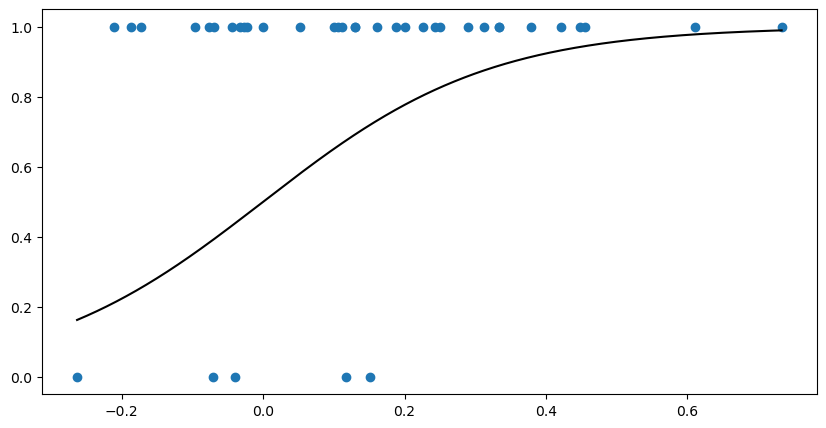

In [738]:
def sig(x):
    return 1 / (1 + np.exp(-x))
#defining it again for our use 

mini = bbgames['Q2fraction'].min()
maxi = bbgames['Q2fraction'].max()

linspace = np.linspace(mini, maxi, 1000)

sigma = sig( (intercept[0] + coef[0][0]) * x)
plt.figure(figsize = (10, 5))
plt.scatter(bbgames['Q2fraction'], bbgames['Result'])


plt.plot(linspace, sigma, color = 'black')

#### Question 3.7

Compute the accuracy, precision, and recall of your best model. **Use a threshold of 0.5 for classification**.

In [810]:
# 7 points
model = LogisticRegression(C = 1000)
model.fit(bbgames[['Q2fraction']], bbgames['Result'])

prob = model.predict_proba(bbgames[['Q2fraction']])[:,1] # preds = lrm_fit.predict_proba(xs)[:,1] from prediction_inference.ipynb lecture week 8
preds = (prob >= 0.5).astype(int) #gives us a bool list, turn into int for values to use (1, 0)

real = bbgames['Result'].values

TN = sum((preds == 0) & (real == 0)) # was normally adding, but we want both conditions to be true 

FN = sum((preds == 0) & (real == 1))

# a test result or alert incorrectly indicating a condition, disease, or threat is present when it's not
FP = sum((preds == 1) & (real == 0))

# when a test or system correctly identifies a positive condition or event that is actually present
TP = sum((preds == 1) & (real == 1))

# accuracy = np.sum(y_preds == y)/len(y) from prediction_inference lecture.ipynb
# going back to classification_15.pdf slides, the formulas are there for this 

accuracy = np.sum(preds == real) / len(bbgames)
precision = TP / (TP + FP)
recall = TP / (TP + FN)
(TN, FN, FP, TP, accuracy, precision, recall)

(0, 0, 5, 33, 0.868421052631579, 0.868421052631579, 1.0)

#### Question 3.8

Think of the order of your 4 models in terms of their loss. Which quarters were better predictors of a win and which were worse predictors. Why do you expect this might be?

In [811]:
feature_error

array([0.53055253, 0.27917082, 0.55172301, 0.37599353])

**Your response**: from our results above, our Q2fraction (aka 2nd quarter) gave us our lowest log loss from all the other ones, meaning that the 2nd quarter in the game had the biggest impact on whether a team was going to win the game. After that, our next best one was the last quarter, which makes sense since that's the last chance you have to win the game and usually, that's when the most goes down.

As far as our 1st and 3rd quarter, they are a lot higher and are usually due to both coming from a break. This makes sense since the 2nd and 4th quarter, you have already been playing with little to no rest and are already warmed up / in the flow state. 

#### Question 3.9

If you were betting money on the outcome of a game, would you prefer to optimize for accuracy, precision, or recall. Explain your answer. 

**Your response**: I think that i would pick precision, because precision measures "Of all observaions that were predicted to be 1, what proportion were actually 1?". Precision tells us that when our model predicts a win(1),  it usually is a win. In this case, maximizing prediction cuts off fewer false positives.

### Question 4

For the final part, we will fit a multiple logistic regression model to predict whether a tissue sample from a biopsied breast mass is maligant or benign using a number of measured characteristics of the sample.

Read in `breast_cancer.csv`. Data from https://archive.ics.uci.edu/dataset/17/breast+cancer+wisconsin+diagnostic

    diagnosis: M = malignant, B = benign
    radius: distances from center to points on the perimeter
    texture: standard deviation of gray-scale values
    smoothness: local variation in radius lengths
    compactness: perimeter^2 / area - 1.0
    symmetry
    fractal dimension: "coastline approximation" - 1


In [945]:
bc = pd.read_csv('data/breast_cancer.csv')
bc.head()

,id,diagnosis,radius_mean,texture_mean,smoothness_mean,compactness_mean,symmetry_mean,fractal_dimension_mean,radius_se,texture_se,smoothness_se,compactness_se,symmetry_se,fractal_dimension_se
0,842302,M,17.99,10.38,0.11840,0.27760,0.2419,0.07871,1.0950,0.9053,0.006399,0.04904,0.03003,0.006193
1,842517,M,20.57,17.77,0.08474,0.07864,0.1812,0.05667,0.5435,0.7339,0.005225,0.01308,0.01389,0.003532
2,84300903,M,19.69,21.25,0.10960,0.15990,0.2069,0.05999,0.7456,0.7869,0.006150,0.04006,0.02250,0.004571
3,84348301,M,11.42,20.38,0.14250,0.28390,0.2597,0.09744,0.4956,1.1560,0.009110,0.07458,0.05963,0.009208
4,84358402,M,20.29,14.34,0.10030,0.13280,0.1809,0.05883,0.7572,0.7813,0.011490,0.02461,0.01756,0.005115


In [946]:
y = bc["diagnosis"].replace({"M":1,"B":0})
X = bc.drop(["id","diagnosis"], axis = 1)

/var/folders/53/qn2bqxzd489fdf7zn6smrbtw0000gn/T/ipykernel_97565/3366068328.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  y = bc["diagnosis"].replace({"M":1,"B":0})


#### Question 4.1

The plan is to determine which of the anatomical characteristics of the tissue sample are the most important for predicting malignancy. (1) Standardize your features (X) and (2) split your data into train and test sets.

In [947]:
# using PCA.ipynb from week 5
from sklearn.preprocessing import StandardScaler

standard = StandardScaler()
X_standard = standard.fit_transform(X)

X_train, X_test, Y_train, Y_test = train_test_split(X_standard, y, test_size = 0.25)

#### Question 4.2

Now compare models of different strengths of regularization (provided) using *k-fold cross-validation*. Use whatever *k* you prefer. The `C =` argument is how you set the penalty when creating the model.

In [951]:
Cs = [.0001, 0.001, 0.01, 0.1, 1, 10, 100, 1000]


# (x = Cs, y = train_error, label = "Train")
# (x = Cs, y = cv_error, label = "Test")
train_error = np.empty(0)
cv_error = np.empty(0)

kf = KFold(n_splits = 5)

for x in Cs:

    validation_errors = np.empty(0)
    
    for train_idx, valid_idx in kf.split(X_train):
        
        split_X_train, split_X_valid = X_train[train_idx], X_train[valid_idx]
        split_Y_train, split_Y_valid = Y_train.iloc[train_idx], Y_train.iloc[valid_idx] 
    
        model = LogisticRegression(C = x)
        model.fit(split_X_train, split_Y_train)

        ypred = model.predict_proba(split_X_valid)[:,1]
        loss = log_loss(split_Y_valid, ypred)

        validation_errors = np.append(validation_errors, loss)


    cv_error = np.append(cv_error, np.mean(validation_errors)) # computing mean cv loss 

    model = LogisticRegression(C = x) #computing trainng loss 
    
    model.fit(X_train, Y_train)
    
    ypredt = model.predict_proba(X_train)[:,1]
    trainl = log_loss(Y_train, ypredt)

    train_error = np.append(train_error, trainl)

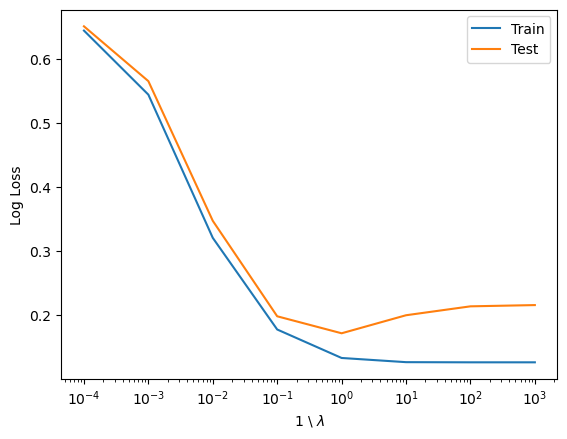

In [952]:
# Plot the two errors
sns.lineplot(x = Cs, y = train_error, label = "Train")
plt.xscale('log')
sns.lineplot(x = Cs, y = cv_error, label = "Test")
plt.xscale('log')
plt.ylabel("Log Loss")
plt.xlabel("1 \ $\lambda$");

Keeping in mind that `C` in `LogisticRegression` is the inverse of our regularization parameter $\lambda$, what can we infer about the effect of regularization on the quality of the model? Does regulating the parameters improve or worsen the fit of the model?

Doing the next question might help you with this question if you're unsure. 

**Your response:** By looking at the graph, we can see that smaller values of C have a stronger reularization, while larger values have weaker regularization. In our graph, with smaller values, we are underfitting, and as we get to the right side of the graph with larger values, our model starts overfitting. This means that too much regularization or too little makes our model worse, so we need to have it at a moderate or centered level. 

#### Question 4.3

When fitting models at different regularization strengths in 4.2, record the values of the coefficients (`model.coef_`) at each strength. Create a lineplot showing the change in the estimated parameters for each variable across the range of regularization strengths. Your x-axis should be the same as the above plot. 

Text(0.5, 1.0, 'Coefficients across Regularization')

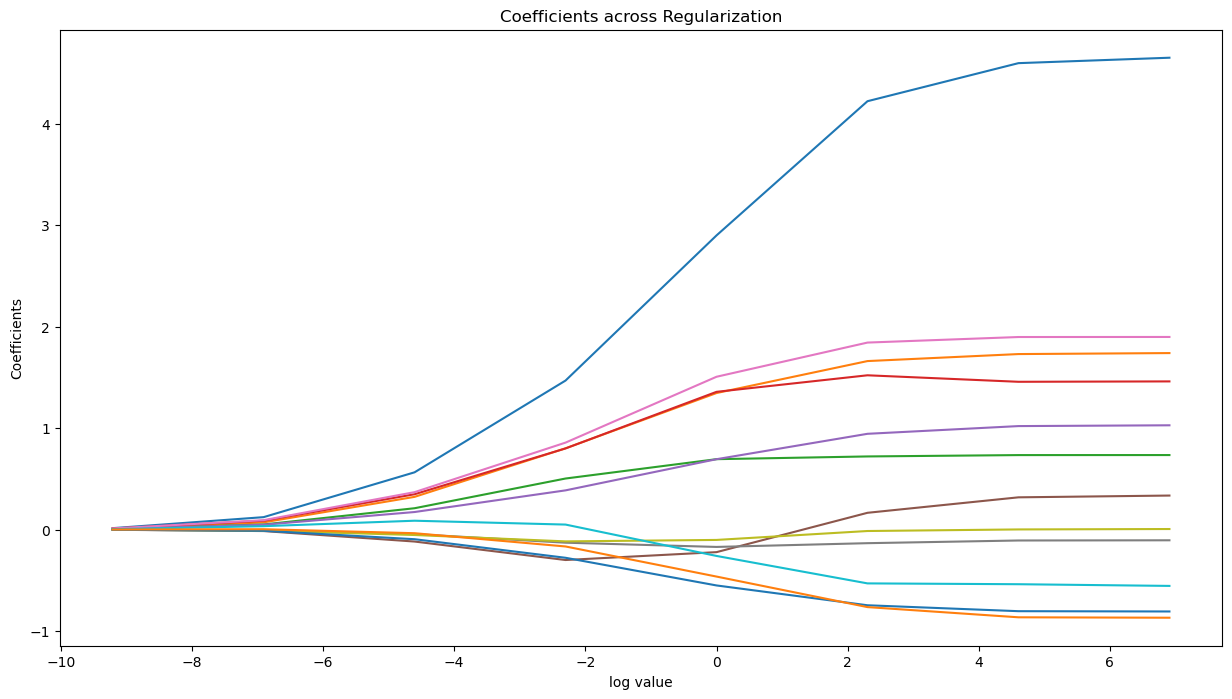

In [1019]:
coefs = []

for x in Cs:
    model = LogisticRegression(C = x)
    model.fit(X_train, Y_train)

    coefs.append(model.coef_[0])

matrix = np.array(coefs)

plt.figure(figsize = (15, 8))

shape = matrix.shape[1]

for x in range(shape):
    sns.lineplot(x = np.log(Cs), y = matrix[:, x]) #taking the log for better visualization, trail and error 

plt.xlabel('log value')
plt.ylabel("Coefficients")
plt.title("Coefficients across Regularization")

Based on the initial coefficients of your standardized variables, as well as the rate at which they shrink with regularization, which variable appear the most important for predicting malignancy?

**Your response:** The most import variable for predicting malignancy is the blue line, since this line has the strongest regularization. It grows much larger than all of the other coefficients , which means that it stays dominant across the whole way.

# Submission

You are now done with the final (and DSCI 311!). 

Make sure you have run all cells in your notebook in order. Then execute the following in the File menu

* Save and Checkpoint
* Close and Halt

Then upload your notebook to Canvas Assignment Final.